In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from types import SimpleNamespace
import jax
#jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import optax
from flax import nnx
from jax import random
import time
import matplotlib.pyplot as plt
import os

In [3]:
import model_funcs
import neural_nets
import solve
import aux
import RANK
import time_iterations


In [4]:
import flax
from flax.core import FrozenDict

print("Flax version:", flax.__version__)

Flax version: 0.12.6


In [5]:
device = aux.choose_gpu()

Avaliable devices:
cuda:0

Device = cuda:0 is choosen


In [6]:
model = RANK.RANK_model(device)

E0423 08:27:46.388378 1037482 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 16.53GiB (17753014272 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0423 08:27:46.388615 1037482 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 14.88GiB (15977712640 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0423 08:27:46.388863 1037482 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 13.39GiB (14379940864 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0423 08:27:46.389049 1037482 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 12.05GiB (12941946880 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0423 08:27:46.389220 1037482 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 10.85GiB (11647752192 by

JaxRuntimeError: INTERNAL: Failed to get configs for: 3 out of 3 instructions. See logs for all failures. Example failure: 
Autotuning failed for HLO: %custom-call.3 = (c64[3,2]{1,0}, s8[4194304]{0}) custom-call(%bitcast.164, %convert_element_type.3), custom_call_target="__cublas$lt$matmul", metadata={op_name="jit(solve_sylvester)/jit(_solve_sylvester_2d)/jit(_solve)/jit(solve)/vmap()/transpose"}, backend_config={"operation_queue_id":"0","gemm_backend_config":{"alpha_real":1,"beta":0,"dot_dimension_numbers":{"lhs_contracting_dimensions":["0"],"rhs_contracting_dimensions":["1"],"lhs_batch_dimensions":[],"rhs_batch_dimensions":[]},"alpha_imag":0,"precision_config":{"operand_precision":["DEFAULT","DEFAULT"],"algorithm":"ALG_UNSET"},"epilogue":"DEFAULT","lhs_stride":"9","rhs_stride":"6","grad_x":false,"grad_y":false,"damax_output":false,"autotune_workspace_size":"0","scale_mode":0},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}. No supported conf

In [ ]:
Y = jnp.linspace(0.5, 1.5, 100)
pi = jnp.linspace(-0.2, 0.2, 100)

from model_funcs import taylor_rule

taylor_rule(model.par, Y, pi, 0.0, 0.0, 0.0, 0.0, 0.0, -100, jnp.ones(1))

NameError: name 'model' is not defined

In [7]:
key = jax

In [8]:
model.linear["P"].T

Array([[-1.1425781 , -1.953125  ],
       [ 0.11553955,  0.19714355],
       [ 0.55908203, -0.2956543 ]], dtype=float32)

In [56]:
x = jnp.linspace(-0.01, 0.01, 100)

i = lambda b: jnp.log(0.01+jnp.exp(b*x-2)) #(x+jnp.sqrt(x**2+4*b**2))/2

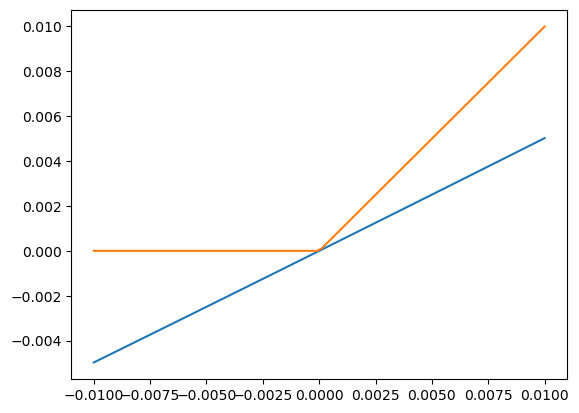

In [59]:
plt.plot(x, (x*1/(1+jnp.exp(-x))))
#plt.plot(x, (0.5+0.5*(1/(jnp.sqrt(x**2 + 1e-10)))))
plt.plot(x, jnp.maximum(x, 0))

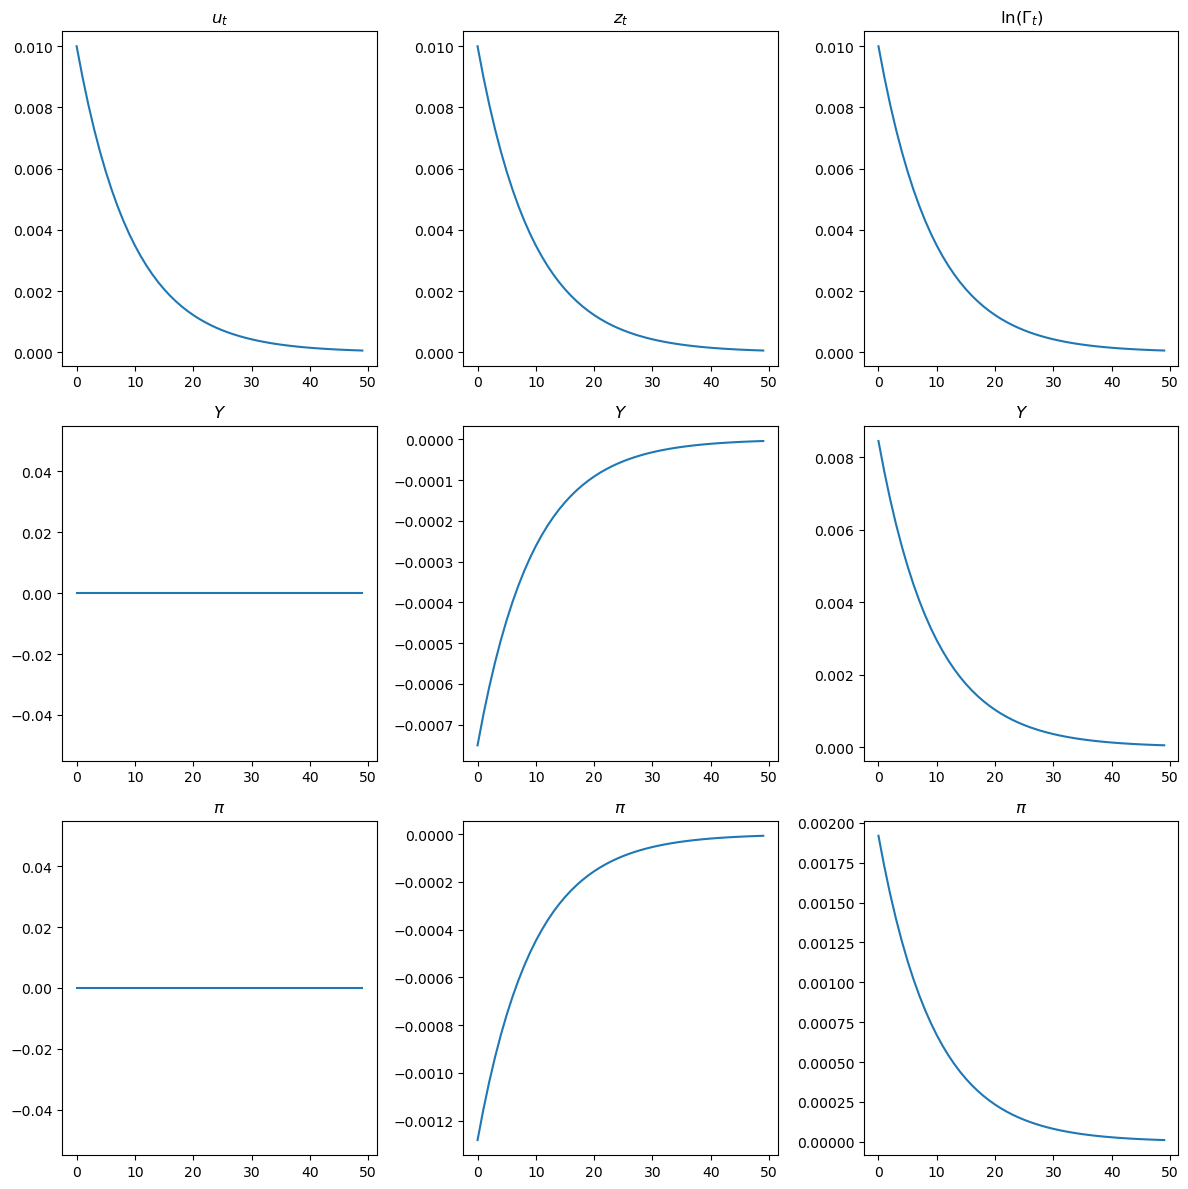

In [9]:
DSS.plot_linear_IRF(model, 0.01)

In [16]:
sigma_list = [0.01] #0.03, 0.04]
episode_list = [200_000] #, 10_000]

solve.train_nn(model, episode_list, 0, sigma_list)

-------------------------------------------------- PHASE 0 --------------------------------------------------
Episode 0:	Loss = 0.00379320	Best Loss = 0.00379320		Y_SSS = 1.193, pi_SSS = -0.000		Errors: Y = -0.01772559, pi = 0.05075746
Episode 50:	Loss = 0.00313297	Best Loss = 0.00313297		Y_SSS = 1.191, pi_SSS = -0.002		Errors: Y = -0.01422811, pi = 0.04750312
Episode 100:	Loss = 0.00262038	Best Loss = 0.00262038		Y_SSS = 1.190, pi_SSS = -0.003		Errors: Y = -0.01118572, pi = 0.04440083
Episode 150:	Loss = 0.00223325	Best Loss = 0.00223325		Y_SSS = 1.188, pi_SSS = -0.004		Errors: Y = -0.00868978, pi = 0.04154320
Episode 200:	Loss = 0.00193931	Best Loss = 0.00193931		Y_SSS = 1.187, pi_SSS = -0.005		Errors: Y = -0.00671705, pi = 0.03890408
Episode 250:	Loss = 0.00171671	Best Loss = 0.00171671		Y_SSS = 1.185, pi_SSS = -0.005		Errors: Y = -0.00530109, pi = 0.03646716
Episode 300:	Loss = 0.00154471	Best Loss = 0.00154471		Y_SSS = 1.184, pi_SSS = -0.006		Errors: Y = -0.00421759, pi = 0.034269

KeyboardInterrupt: 

In [60]:
model.compute_IRF(0.05, 50)

TypeError: dot_general requires contracting dimensions to have the same shape, got (6,) and (12,).

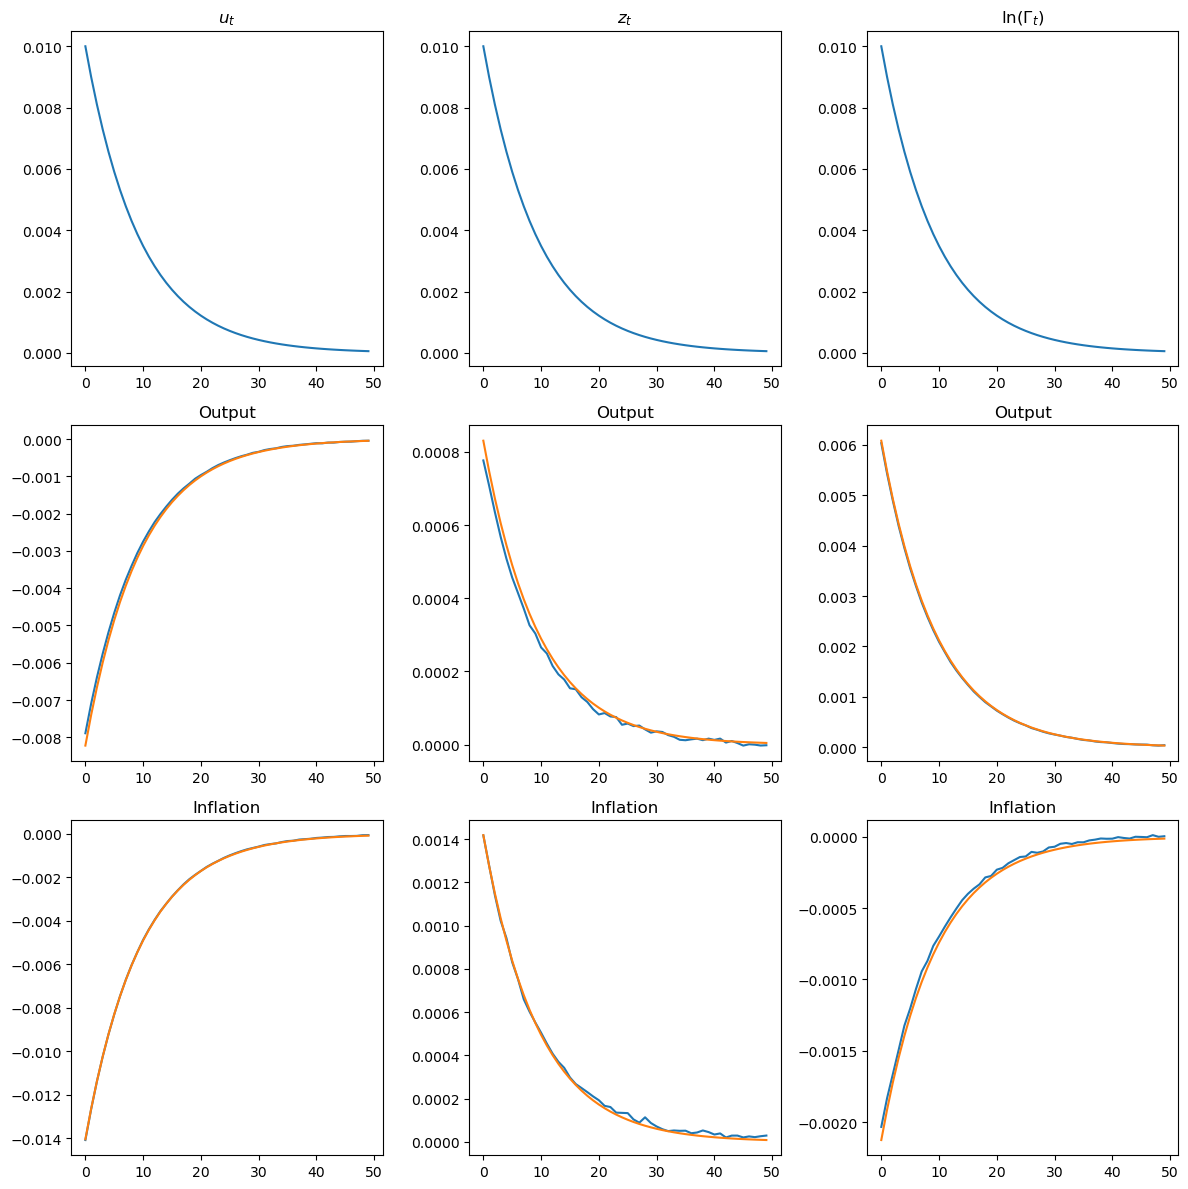

In [61]:
model.plot_IRF()

In [59]:
from solve import loss, construct_gh_nodes
from aux import draw_states_directly

key = jax.random.PRNGKey(42)

final_sigma_dict = {
    "sigma_eps_u" : sigma_list[-1],
    "sigma_eps_z" : sigma_list[-1],
    "sigma_eps_Gamma" : sigma_list[-1]
}
states = draw_states_directly(key, model.par, model.dtype, 100000, final_sigma_dict)

gh_x, gh_w = construct_gh_nodes(model.dtype, 5, 0.01, 0.01, 0.01)

ee, nkpce = loss(model.nn, model.par, model.train, model.linear, model.dtype, states, gh_x, gh_w, return_ee_nkpce=True)

E0413 16:44:37.140243 1809285 xtile_compiler.cc:399] Fusion: gemm_fusion_dot_general.1 = f32[100000,100]{1,0} fusion(args_0_.1, args_1_.1), kind=kCustom, calls=gemm_fusion_dot_general.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"8","output_tiles":[{"sizes":["128","128"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0413 16:44:37.140380 1809285 xtile_compiler.cc:401] Computation: gemm_fusion_dot_general.1_computation.clone {
  parameter_0 = f32[100000,100]{1,0} parameter(0)
  parameter_1 = f32[100,100]{1,0} parameter(1)
  ROOT dot_general.0 = f32[100000,100]{1,0} dot(parameter_0, parameter_1), lhs_contracting_dims={1}, rhs_contracting_dims={0}, backend_config={"sizes":["32"]}
}
W0413 16:44:50.545232 1

JaxRuntimeError: INTERNAL: Autotuning failed for HLO: %gemm_fusion_dot_general.1 = f32[12500000,100]{1,0} fusion(%args_0_.1, %args_1_.1), kind=kCustom, calls=%gemm_fusion_dot_general.1_computation, metadata={op_name="jit(dot_general)/dot_general" stack_frame_id=6}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_gemm"},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"} with error: NOT_FOUND: No valid config found! Failures: 4
EXECUTION FAILED: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 4.66GiB. [tf-allocator-allocation-error='']
EXECUTION FAILED: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 4.66GiB. [tf-allocator-allocation-error='']
EXECUTION FAILED: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 4.66GiB. [tf-allocator-allocation-error='']
EXECUTION FAILED: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 4.66GiB. [tf-allocator-al

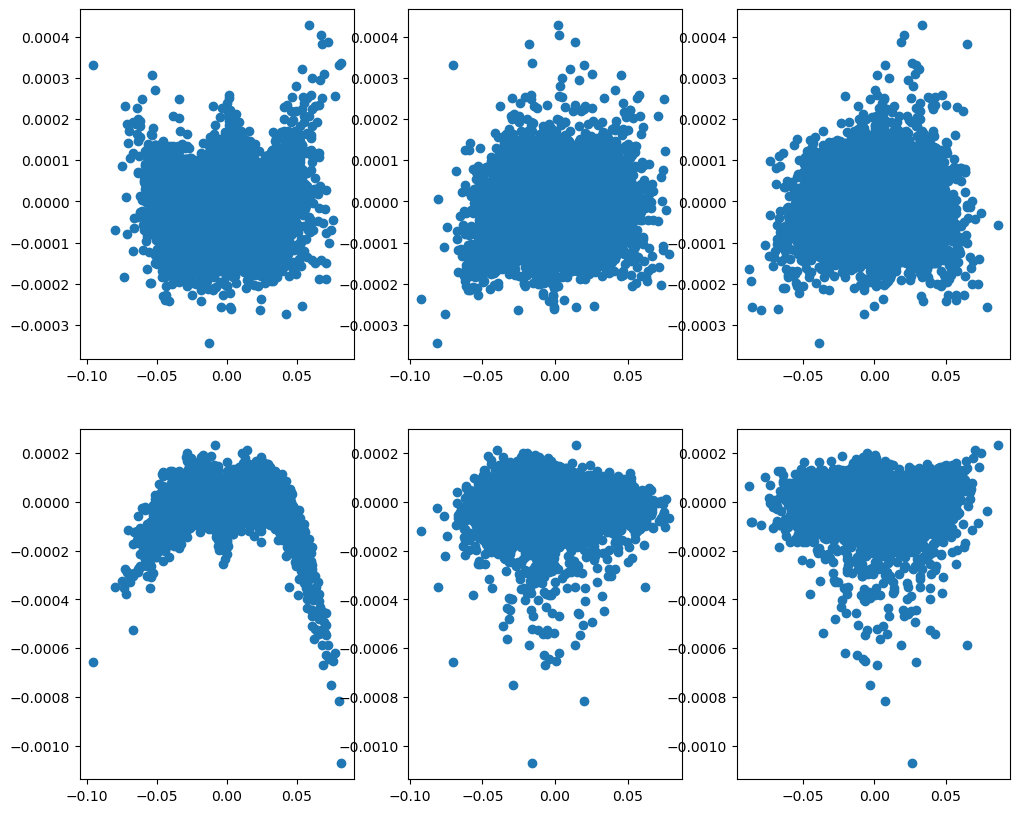

In [58]:
f, ax = plt.subplots(2,3, figsize=(12,10))

for i in range(3): ax[0, i].scatter(states[:, i], ee)
for i in range(3): ax[1, i].scatter(states[:, i], nkpce)

In [62]:
plt.hist(u)

NameError: name 'u' is not defined

In [10]:
from aux import draw_states_directly, next_states_quad
model = RANK.RANK_model(device)

In [11]:
model.par

{'phi': 1.5,
 'sigma': 2.0,
 'beta': 0.99,
 'kappa': 0.05,
 'mu': 1.1,
 'varphi': 2.0,
 'ZLB': -100,
 'Y_DSS': 0.9764540896763105,
 'pi_DSS': 0.0,
 'i_DSS': 0.010101010101010166,
 'u_DSS': 0.0,
 'z_DSS': 0.0,
 'ln_Gamma_DSS': 0.0,
 'rho_u': 0.9,
 'sigma_eps_u': 0.04358898848295212,
 'mu_u': 0.0,
 'rho_z': 0.9,
 'sigma_eps_z': 0.04358898848295212,
 'mu_z': 0.0,
 'rho_Gamma': 0.9,
 'sigma_eps_Gamma': 0.04358898848295212,
 'mu_Gamma': 0.0,
 'Rho': Array([[0.9, 0. , 0. ],
        [0. , 0.9, 0. ],
        [0. , 0. , 0.9]], dtype=float32),
 'Mu': Array([[0.],
        [0.],
        [0.]], dtype=float32),
 'Nshocks': 3,
 'Nstates': 3,
 'Npolicies': 2}

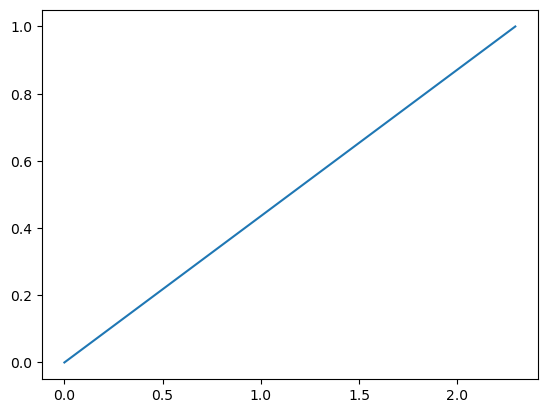

In [12]:
sigma_eps = np.linspace(0,1,1000)
rho = 0.9
sigma_states = sigma_eps/np.sqrt(1-rho**2)
plt.plot(sigma_states, sigma_eps)

In [13]:
0.04/np.sqrt(1-rho**2)

np.float64(0.09176629354822473)

In [14]:
states = jnp.zeros((100,3))

In [15]:
model.train["gh_x"]

Array([[-0.10175476, -0.10175476, -0.10175476],
       [-0.10175476, -0.10175476, -0.03234145],
       [-0.10175476, -0.10175476,  0.03234145],
       [-0.10175476, -0.10175476,  0.10175476],
       [-0.10175476, -0.03234145, -0.10175476],
       [-0.10175476, -0.03234145, -0.03234145],
       [-0.10175476, -0.03234145,  0.03234145],
       [-0.10175476, -0.03234145,  0.10175476],
       [-0.10175476,  0.03234145, -0.10175476],
       [-0.10175476,  0.03234145, -0.03234145],
       [-0.10175476,  0.03234145,  0.03234145],
       [-0.10175476,  0.03234145,  0.10175476],
       [-0.10175476,  0.10175476, -0.10175476],
       [-0.10175476,  0.10175476, -0.03234145],
       [-0.10175476,  0.10175476,  0.03234145],
       [-0.10175476,  0.10175476,  0.10175476],
       [-0.03234145, -0.10175476, -0.10175476],
       [-0.03234145, -0.10175476, -0.03234145],
       [-0.03234145, -0.10175476,  0.03234145],
       [-0.03234145, -0.10175476,  0.10175476],
       [-0.03234145, -0.03234145, -0.101

In [16]:
next_states_quad(model.par, states, model.train["gh_x"]).shape

TypeError: next_states_quad() missing 1 required positional argument: 'gh_x'

In [ ]:
from model_funcs import euler_error

In [ ]:
DSS.compute_linear_policy(model)

In [ ]:
P_Y = model.linear["P"][0]
P_pi = model.linear["P"][1]

In [ ]:
P_Y

Array([-1.1914062 ,  0.12536621,  0.5161133 ], dtype=float32)

In [ ]:
states = draw_states_directly(model.par, 100000)

u = states[:, 0]
z = states[:, 1]
G = states[:, 2]

print(u.mean(), z.mean(), G.mean())
print(u.std(), z.std(), G.std())
print(0, np.exp(z).mean(), np.exp(G).mean())

-7.98929e-06 1.258085e-05 2.141494e-05
0.009994819 0.010026593 0.00996501
0 1.000063 1.0000712


(array([4.000e+00, 3.000e+00, 1.000e+00, 5.000e+00, 2.000e+00, 6.000e+00,
        7.000e+00, 6.000e+00, 1.300e+01, 1.400e+01, 1.300e+01, 2.800e+01,
        3.300e+01, 5.000e+01, 6.400e+01, 6.400e+01, 8.200e+01, 1.130e+02,
        1.360e+02, 1.970e+02, 2.150e+02, 2.600e+02, 3.230e+02, 3.690e+02,
        4.410e+02, 5.180e+02, 5.710e+02, 6.760e+02, 8.370e+02, 9.520e+02,
        1.113e+03, 1.221e+03, 1.389e+03, 1.448e+03, 1.639e+03, 1.773e+03,
        2.032e+03, 2.111e+03, 2.266e+03, 2.416e+03, 2.574e+03, 2.702e+03,
        2.891e+03, 2.932e+03, 3.151e+03, 3.119e+03, 3.246e+03, 3.227e+03,
        3.293e+03, 3.275e+03, 3.212e+03, 3.123e+03, 3.115e+03, 3.030e+03,
        2.794e+03, 2.772e+03, 2.669e+03, 2.507e+03, 2.403e+03, 2.205e+03,
        2.002e+03, 1.890e+03, 1.844e+03, 1.604e+03, 1.452e+03, 1.288e+03,
        1.158e+03, 1.011e+03, 9.220e+02, 7.720e+02, 6.850e+02, 6.230e+02,
        5.010e+02, 4.790e+02, 3.920e+02, 3.150e+02, 2.820e+02, 2.080e+02,
        1.870e+02, 1.530e+02, 1.180e+0

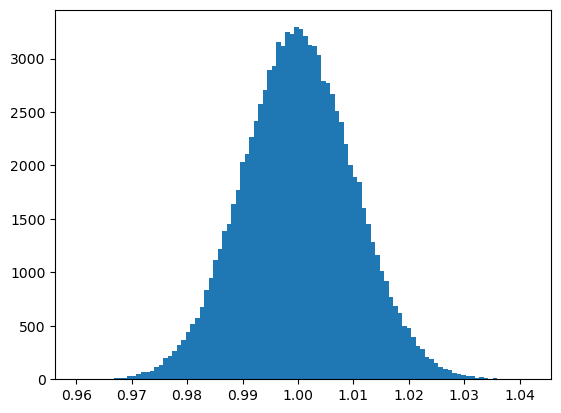

In [ ]:
plt.hist(np.exp(states[:,2]), bins=100)

(array([1.000e+00, 1.000e+00, 2.000e+00, 3.000e+00, 2.000e+00, 0.000e+00,
        2.000e+00, 7.000e+00, 3.000e+00, 8.000e+00, 1.600e+01, 1.200e+01,
        1.700e+01, 2.900e+01, 4.000e+01, 5.600e+01, 4.600e+01, 7.500e+01,
        9.700e+01, 1.200e+02, 1.500e+02, 1.570e+02, 2.280e+02, 2.980e+02,
        2.980e+02, 3.940e+02, 4.600e+02, 6.180e+02, 6.420e+02, 7.440e+02,
        9.360e+02, 1.099e+03, 1.242e+03, 1.408e+03, 1.571e+03, 1.712e+03,
        1.908e+03, 2.068e+03, 2.197e+03, 2.490e+03, 2.700e+03, 2.777e+03,
        3.013e+03, 3.187e+03, 3.207e+03, 3.281e+03, 3.436e+03, 3.472e+03,
        3.519e+03, 3.519e+03, 3.459e+03, 3.450e+03, 3.500e+03, 3.376e+03,
        3.114e+03, 2.949e+03, 2.895e+03, 2.561e+03, 2.529e+03, 2.255e+03,
        2.077e+03, 1.907e+03, 1.756e+03, 1.610e+03, 1.399e+03, 1.197e+03,
        1.098e+03, 8.900e+02, 8.340e+02, 6.400e+02, 5.780e+02, 5.020e+02,
        4.080e+02, 3.760e+02, 2.840e+02, 2.190e+02, 1.860e+02, 1.530e+02,
        1.180e+02, 1.080e+02, 7.100e+0

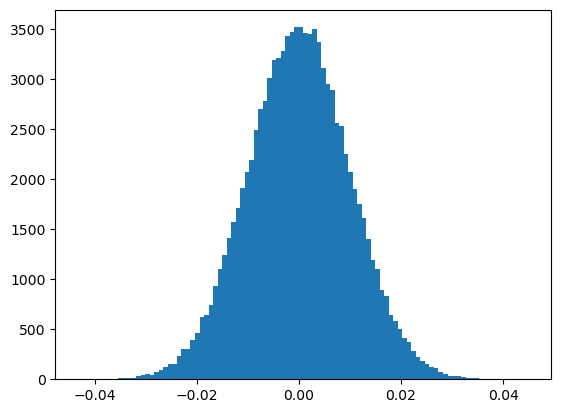

In [ ]:
plt.hist(u, bins=100)

In [ ]:
u.std()

Array(0.00999482, dtype=float32)

In [ ]:
model.train['gh_x']

Array([[-0.01017547, -0.01017547, -0.01017547],
       [-0.01017547, -0.01017547, -0.00323415],
       [-0.01017547, -0.01017547,  0.00323415],
       [-0.01017547, -0.01017547,  0.01017547],
       [-0.01017547, -0.00323415, -0.01017547],
       [-0.01017547, -0.00323415, -0.00323415],
       [-0.01017547, -0.00323415,  0.00323415],
       [-0.01017547, -0.00323415,  0.01017547],
       [-0.01017547,  0.00323415, -0.01017547],
       [-0.01017547,  0.00323415, -0.00323415],
       [-0.01017547,  0.00323415,  0.00323415],
       [-0.01017547,  0.00323415,  0.01017547],
       [-0.01017547,  0.01017547, -0.01017547],
       [-0.01017547,  0.01017547, -0.00323415],
       [-0.01017547,  0.01017547,  0.00323415],
       [-0.01017547,  0.01017547,  0.01017547],
       [-0.00323415, -0.01017547, -0.01017547],
       [-0.00323415, -0.01017547, -0.00323415],
       [-0.00323415, -0.01017547,  0.00323415],
       [-0.00323415, -0.01017547,  0.01017547],
       [-0.00323415, -0.00323415, -0.010

In [ ]:
model = RANK.RANK_model(device)
model.load('output/monday30march.pkl')

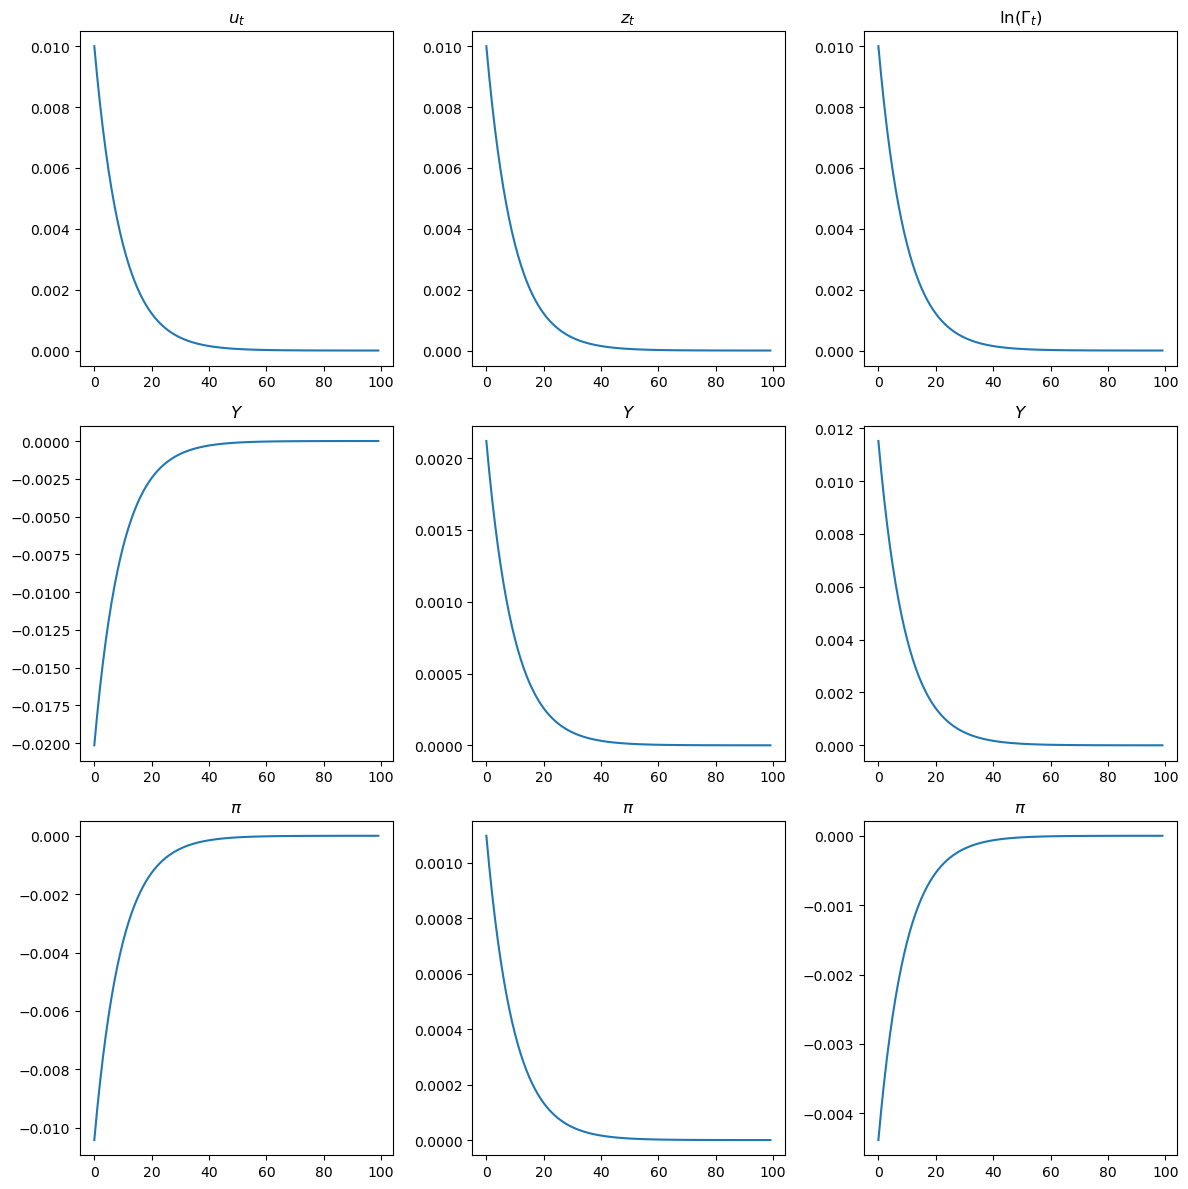

In [ ]:
DSS.compute_linear_policy(model)
DSS.plot_linear_IRF(model, 0.01)

In [ ]:
DSS.simulate_linear_policy(model, jnp.zeros((1,3)))

Array([[1., 0.]], dtype=float32)

In [ ]:
model.linear

namespace(P=Array([[-2.0136719 ,  0.21191406,  1.1513672 ],
                   [-1.0419922 ,  0.10968018, -0.43847656]], dtype=float32))

In [ ]:
nn_y = lambda x: model.nn(x)[0]
nn_grad = jax.grad(nn_y)

In [ ]:
nn_grads_u = nn_grad(jnp.zeros(150))[:50]

In [ ]:
Y_SSS, pi_SSS = model.nn(jnp.zeros(150))

In [ ]:
u_lin = DSS.compute_linear_policy_atpoint(model, Y_SSS, Y_SSS, pi_SSS, pi_SSS, 0.0, 0.0, 0.0, 0.0)[:,0]

In [ ]:
lin_grads = np.flip(u_lin[0]*model.par["rho_i"]**np.arange(50))

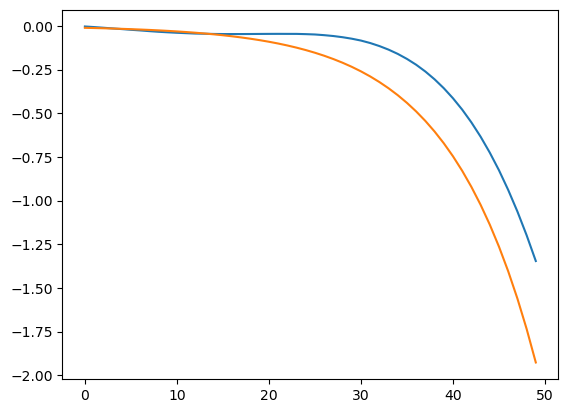

In [ ]:
plt.plot(nn_grads_u)
plt.plot(lin_grads)

In [ ]:
nn_grads_u - lin_grads

Array([ 0.00459748,  0.00261057,  0.00041967, -0.00179959, -0.00380492,
       -0.00589422, -0.00752669, -0.00936097, -0.01070659, -0.01126599,
       -0.0114279 , -0.01089253, -0.01013709, -0.00806991, -0.00590683,
       -0.00278869,  0.00111193,  0.00553979,  0.0106558 ,  0.01642009,
        0.02267694,  0.02950479,  0.03681625,  0.04504164,  0.05308765,
        0.06167771,  0.06982711,  0.07834904,  0.08680072,  0.09534695,
        0.1038418 ,  0.11147173,  0.11854685,  0.12535472,  0.13164198,
        0.13724591,  0.14238317,  0.14654444,  0.15006337,  0.15289316,
        0.15497103,  0.15669131,  0.15770257,  0.15846187,  0.15881181,
        0.15961611,  0.16040486,  0.16255045,  0.16613263,  0.17239141],      dtype=float32)

In [ ]:
ee_off = model_funcs.euler_error(model.par, Y_SSS, Y_SSS, pi_SSS, pi_SSS, 0.0, 0.0, 0.0, jnp.ones(1))

In [ ]:
ee_off

Array([0.025141], dtype=float32)